# 🎫 Support Ticket Classification & Prioritization using Machine Learning

### Future Interns – ML Task 2

This project focuses on automatically **classifying customer support tickets and predicting their priority levels** using Natural Language Processing (NLP) and Machine Learning techniques.

---

## 🎯 Project Goal

The objective of this project is to analyze support ticket text data and build a machine learning model that can automatically classify tickets into categories and assign priority levels. Such automation helps organizations handle customer issues faster, improve response time, and optimize support team workflows.

# 📦 Step 1: Install Required Libraries

Before starting the project we install the required Python libraries.

These libraries help with:

- Data processing
- Natural language processing
- Machine learning
- Visualization

In [15]:
!pip install pandas numpy scikit-learn nltk matplotlib seaborn streamlit


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# 📚 Step 2: Import Required Libraries

Now we import all the libraries required for:

- Data analysis
- NLP preprocessing
- Machine learning models
- Data visualization

In [2]:
import pandas as pd
import numpy as np
import re
import string

import matplotlib.pyplot as plt
import seaborn as sns

import nltk

# 📥 Step 3: Download NLTK Resources

NLTK requires additional datasets for:

- Tokenization
- Stopword removal
- Lemmatization

We download them once before using NLP functions.

In [3]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Amrutha\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Amrutha\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Amrutha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Amrutha\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Amrutha\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

# 📂 Step 4: Load the Dataset

We load the **Customer Support Ticket dataset**.

Important columns in this dataset include:

- Ticket Subject
- Ticket Description
- Ticket Type
- Ticket Priority

In [4]:
df = pd.read_csv("customer_support_tickets.csv")

df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


# 🔍 Step 5: Dataset Overview

Before processing the data we inspect:

- dataset size
- column names
- missing values

In [5]:
df.info()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64

# 🧹 Step 6: Data Cleaning

Real-world datasets contain missing values.

We replace missing values in:

- Ticket Subject
- Ticket Description

In [6]:
df["Ticket Subject"] = df["Ticket Subject"].fillna("")
df["Ticket Description"] = df["Ticket Description"].fillna("")

# 🧩 Step 7: Combine Text Fields

We combine **subject and description** into one column.

This gives the model more context about the support ticket.

In [7]:
df["text"] = df["Ticket Subject"] + " " + df["Ticket Description"]

df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,text
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN,Product setup I'm having an issue with the {pr...
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN,Peripheral compatibility I'm having an issue w...
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0,Network problem I'm facing a problem with my {...
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0,Account access I'm having an issue with the {p...
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0,Data loss I'm having an issue with the {produc...


# 🧠 Step 8: Text Preprocessing (NLP)

Machine learning models cannot understand raw text.

So we apply NLP techniques:

- Lowercasing
- Removing punctuation
- Tokenization
- Stopword removal
- Lemmatization

In [8]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess(text):

    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    text = text.translate(str.maketrans("", "", string.punctuation))

    tokens = word_tokenize(text)

    tokens = [t for t in tokens if t not in stop_words]

    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return " ".join(tokens)

# ✨ Step 9: Apply Text Preprocessing

Now we apply the preprocessing function to all tickets.

In [11]:
df["clean_text"] = df["text"].apply(preprocess)

df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating,text,clean_text
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN,Product setup I'm having an issue with the {pr...,product setup im issue productpurchased please...
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN,Peripheral compatibility I'm having an issue w...,peripheral compatibility im issue productpurch...
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0,Network problem I'm facing a problem with my {...,network problem im facing problem productpurch...
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0,Account access I'm having an issue with the {p...,account access im issue productpurchased pleas...
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0,Data loss I'm having an issue with the {produc...,data loss im issue productpurchased please ass...


## 📊 Step 10: Visualizing Ticket Category Distribution

In this step, we perform **Exploratory Data Analysis (EDA)** to understand how support tickets are distributed across different categories.

We create a **count plot** using the Seaborn visualization library to display the number of tickets belonging to each **Ticket Type**.

### Why This Step is Important

Understanding the distribution of ticket categories helps us:

- Identify the most common types of customer issues
- Detect potential **class imbalance** in the dataset
- Gain insights into support trends

### Visualization Used

A **countplot** is used to display the frequency of each ticket category.  
Rotating the labels ensures better readability when category names are long.

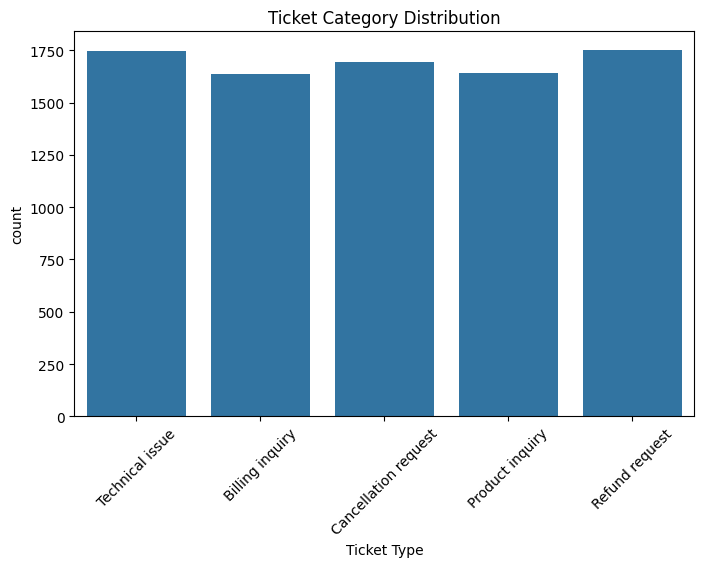

In [10]:
plt.figure(figsize=(8,5))
sns.countplot(x="Ticket Type", data=df)
plt.xticks(rotation=45)
plt.title("Ticket Category Distribution")
plt.show()

## ⚡ Step 11: Visualizing Ticket Priority Distribution

Next, we analyze the distribution of ticket priorities within the dataset.

Each support ticket is assigned a **priority level**, indicating how urgent the issue is.

Typical priority levels include:

- 🔴 Critical
- 🟠 High
- 🟡 Medium
- 🟢 Low

### Purpose of This Visualization

By visualizing ticket priorities, we can:

- Understand how urgent customer issues typically are
- Detect imbalances between priority levels
- Evaluate whether the dataset contains enough examples of each priority class

This information helps ensure the machine learning model can **learn meaningful patterns when predicting ticket priority**.

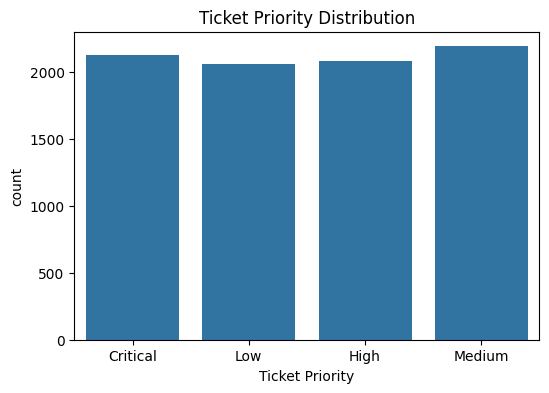

In [12]:
plt.figure(figsize=(6,4))
sns.countplot(x="Ticket Priority", data=df)
plt.title("Ticket Priority Distribution")
plt.show()

## 🔢 Step 12: Feature Extraction using TF-IDF

Machine learning algorithms cannot process raw text directly.  
Therefore, we need to convert textual data into **numerical representations**.

In this step, we use **TF-IDF (Term Frequency–Inverse Document Frequency)** vectorization to transform the cleaned ticket text into numerical feature vectors.

### What is TF-IDF?

TF-IDF measures the importance of a word within a document relative to the entire dataset.

It works by:

1. Counting how often a word appears in a document
2. Reducing the importance of words that appear frequently across many documents

### Why Use TF-IDF?

TF-IDF helps the model focus on **important keywords that differentiate support tickets**.

For example:

- Words like **error**, **refund**, or **login** may strongly indicate specific ticket types.

The `max_features=5000` parameter limits the number of vocabulary terms used by the model.

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df["clean_text"])

## 🎯 Step 13: Defining Target Variables

In supervised machine learning, we must clearly define the **target variables** that the model will learn to predict.

In this project, we focus on two prediction tasks:

### 1️⃣ Ticket Category Prediction

The **Ticket Type** column represents the category of the support ticket.

Examples may include:

- Technical Issues
- Billing Problems
- Account Access
- General Inquiries

Our model will learn to **automatically classify incoming tickets into these categories**.

### 2️⃣ Ticket Priority Prediction

The **Ticket Priority** column represents the urgency level of the ticket.

Predicting priority helps support teams:

- Identify urgent issues quickly
- Allocate resources efficiently
- Improve response time

We store these target variables as `y_category` and `y_priority`.

In [14]:
y_category = df["Ticket Type"]
y_priority = df["Ticket Priority"]

## 🔀 Step 14: Splitting Data into Training and Testing Sets

To evaluate the performance of a machine learning model, we divide the dataset into two parts:

| Dataset | Purpose |
|-------|--------|
| **Training Set** | Used to train the machine learning model |
| **Testing Set** | Used to evaluate model performance |

### Train-Test Split

In this project:

- **80% of the data** is used for training
- **20% of the data** is used for testing

This ensures that the model is evaluated on **data it has never seen before**, which provides a realistic measure of its predictive performance.

The `random_state=42` parameter ensures reproducibility of results.

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_category, test_size=0.2, random_state=42
)

## 🤖 Step 15: Training Machine Learning Models

In this step, we train several machine learning algorithms to classify support tickets.

Using multiple models allows us to compare their performance and choose the most effective one.

### Models Used

| Model | Description |
|------|-------------|
| **Naive Bayes** | A probabilistic classifier commonly used for text classification |
| **Logistic Regression** | A linear model used for classification problems |
| **Support Vector Machine (SVM)** | A powerful classifier that performs well on high-dimensional text data |

Each model is trained using the **training dataset**, where it learns patterns that associate ticket text with the correct category.

In [18]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

nb = MultinomialNB()
lr = LogisticRegression(max_iter=1000)
svm = LinearSVC()

nb.fit(X_train, y_train)
lr.fit(X_train, y_train)
svm.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

## 📈 Step 16: Evaluating Model Performance

After training the models, we evaluate their performance using the **test dataset**.

The evaluation is performed using the **classification report**, which provides several important metrics:

| Metric | Meaning |
|------|--------|
| **Precision** | Accuracy of positive predictions |
| **Recall** | Ability of the model to detect actual positives |
| **F1 Score** | Balance between precision and recall |
| **Support** | Number of true instances for each class |

These metrics help determine how well the model performs across different ticket categories.

In [19]:
from sklearn.metrics import classification_report

pred_nb = nb.predict(X_test)

print(classification_report(y_test, pred_nb))

                      precision    recall  f1-score   support

     Billing inquiry       0.12      0.04      0.06       357
Cancellation request       0.18      0.16      0.17       327
     Product inquiry       0.15      0.13      0.14       316
      Refund request       0.20      0.30      0.24       345
     Technical issue       0.22      0.31      0.26       349

            accuracy                           0.19      1694
           macro avg       0.17      0.19      0.17      1694
        weighted avg       0.17      0.19      0.17      1694



## ⚡ Step 17: Training the Ticket Priority Prediction Model

In addition to classifying ticket categories, we also build a model to predict **ticket priority levels**.

This is treated as a separate classification problem.

We again split the dataset into training and testing sets, but this time the target variable is **Ticket Priority**.

A **Logistic Regression model** is used to learn patterns that associate ticket text with the correct priority level.

Predicting ticket priority helps support teams **prioritize critical issues and improve service efficiency**.

In [21]:
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X, y_priority, test_size=0.2, random_state=42
)

priority_model = LogisticRegression(max_iter=1000)

priority_model.fit(X_train_p, y_train_p)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## 🔍 Step 18: Creating a Ticket Classification Function

To make the model easy to use, we define a function called `classify_ticket()`.

This function performs the entire prediction pipeline:

1️⃣ Preprocess the input ticket text  
2️⃣ Convert the text into TF-IDF features  
3️⃣ Predict the ticket category  
4️⃣ Predict the ticket priority  

### Why This Function is Useful

This function allows us to quickly test the model with new ticket descriptions.

For example, a support agent could input a ticket like:
  "My account is locked and I cannot log in"


In [23]:
def classify_ticket(text):

    clean = preprocess(text)

    vector = vectorizer.transform([clean])

    category = svm.predict(vector)[0]

    priority = priority_model.predict(vector)[0]

    return category, priority

In [24]:
classify_ticket("My account was hacked and I cannot login")

('Cancellation request', 'Medium')

## 🎉 Conclusion

In this project, we built a machine learning system that classifies customer support tickets and predicts their priority using Natural Language Processing and TF-IDF features.  
Multiple machine learning models were trained and evaluated to identify patterns in support ticket data.  
The final system can help automate ticket categorization and improve customer support efficiency.

In [26]:
import pickle

# Save models
pickle.dump(svm, open("category_model.pkl", "wb"))
pickle.dump(priority_model, open("priority_model.pkl", "wb"))

# Save vectorizer
pickle.dump(vectorizer, open("tfidf_vectorizer.pkl", "wb"))